# 08 — RNN surrogates over grid time series

physicsnemo's RNN pattern (`One2ManyRNN`, the 2D Navier–Stokes / Gray–Scott examples) predicts a
whole trajectory from **one** state: `(N, C, 1, H, W) → (N, C, T, H, W)`. This notebook closes the
loop around it with Kratos:

1. a transient field on a Kratos mesh is exported as a **grid series** (`GridDatasetExportProcess`),
2. `CreateGridSequenceDataset` pairs each state with its `T` successors and `TrainModel` trains a
   `One2ManyRNN` unchanged,
3. `SequenceInferenceProcess` seeds the model once inside a solution loop and writes one predicted
   state per step.

The transient field is an analytically diffusing (and drifting) Gaussian blob — cheap, smooth, and
with a known ground truth at every time.


In [1]:
import math
from pathlib import Path

import numpy
import torch

import KratosMultiphysics as Kratos
from KratosMultiphysics.PhysicsNeMoApplication.processes.export import grid_dataset_export_process
from KratosMultiphysics.PhysicsNeMoApplication.processes.inference import sequence_inference_process
from KratosMultiphysics.PhysicsNeMoApplication.training import training_utils
from KratosMultiphysics.PhysicsNeMoApplication.training.torch_dataset import CreateGridSequenceDataset

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)

# Kratos hexahedron corners -> 6 tetrahedra (fan), for a quick structured mesh
_HEX_TO_TETS = ((0, 1, 2, 6), (0, 2, 3, 6), (0, 3, 7, 6), (0, 7, 4, 6), (0, 4, 5, 6), (0, 5, 1, 6))

def create_tet_cube(model, name, divisions):
    model_part = model.CreateModelPart(name)
    model_part.AddNodalSolutionStepVariable(Kratos.TEMPERATURE)
    props = model_part.CreateNewProperties(1)
    n = divisions + 1
    for i in range(n):
        for j in range(n):
            for k in range(n):
                model_part.CreateNewNode(i * n * n + j * n + k + 1,
                                         i / divisions, j / divisions, k / divisions)
    nid = lambda i, j, k: i * n * n + j * n + k + 1
    element_id = 0
    for i in range(divisions):
        for j in range(divisions):
            for k in range(divisions):
                corners = [nid(i, j, k), nid(i + 1, j, k), nid(i + 1, j + 1, k), nid(i, j + 1, k),
                           nid(i, j, k + 1), nid(i + 1, j, k + 1), nid(i + 1, j + 1, k + 1), nid(i, j + 1, k + 1)]
                for tet in _HEX_TO_TETS:
                    element_id += 1
                    model_part.CreateNewElement("Element3D4N", element_id, [corners[c] for c in tet], props)
    return model_part

def blob(x, y, t):
    """A Gaussian blob spreading (D) and drifting (v) in time — the ground truth."""
    width = 0.02 + 0.008 * t
    cx, cy = 0.35 + 0.012 * t, 0.45
    r2 = (x - cx) ** 2 + (y - cy) ** 2
    return (0.02 / width) * math.exp(-r2 / (2.0 * width))

def set_blob(model_part, t):
    for node in model_part.Nodes:
        node.SetSolutionStepValue(Kratos.TEMPERATURE, blob(node.X, node.Y, t))

model = Kratos.Model()
model_part = create_tet_cube(model, "Main", divisions=6)
print(model_part)


 |  /           |                  
 ' /   __| _` | __|  _ \   __|    
 . \  |   (   | |   (   |\__ \  
_|\_\_|  \__,_|\__|\___/ ____/
           Multi-Physics 10.4."2"-physicsnemo-application-e03638205c2-Release-x86_64
           Compiled for GNU/Linux and Python3.12 with GCC-13.3
Compiled with threading and MPI support. Threading support with OpenMP.
Maximum number of threads: 2.
Running without MPI.
Importing    KratosPhysicsNeMoApplication 
 ______  _                _            ______        ______                           _ _                 _            
(_____ \| |              (_)          |  ___ \      |  ___ \         /\              | (_)           _   (_)            
 _____) ) | _  _   _  ___ _  ____  ___| |   | | ____| | _ | | ___   /  \  ____  ____ | |_  ____ ____| |_  _  ___  ____  
|  ____/| || \| | | |/___) |/ ___)/___) |   | |/ _  ) || || |/ _ \ / /\ \|  _ \|  _ \| | |/ ___) _  |  _)| |/ _ \|  _ \
| |     | | | | |_| |___ | ( (___|___ | |   | ( (/ /| || || | |_| | |

## Exporting the grid series

`GridDatasetExportProcess` samples the nodal field onto a fixed lattice every step and writes one
`grid_<step>.npz` per state. The field only varies in `x`/`y`, so we use the **thin-axis idiom** for
planar dynamics: `grid_shape [16, 16, 2]` — 16×16 in-plane, a thin axis of 2 across `z` that the
dataset later collapses (`squeeze_axis=2`) to feed a `dimension=2` model.


In [2]:
series_settings = Kratos.Parameters("""{
    "Parameters": {
        "model_part_name" : "Main",
        "list_of_fields"  : [ { "variable_name" : "TEMPERATURE", "data_location" : "node_historical" } ],
        "grid_shape"      : [16, 16, 2],
        "output_path"     : "output/rnn_grid_series"
    }
}""")
export_process = grid_dataset_export_process.Factory(series_settings, model)
export_process.ExecuteInitialize()

N_STEPS = 24
for step in range(1, N_STEPS + 1):
    model_part.ProcessInfo[Kratos.STEP] = step
    model_part.ProcessInfo[Kratos.TIME] = float(step)
    set_blob(model_part, float(step))
    export_process.ExecuteFinalizeSolutionStep()

print(len(list(Path("output/rnn_grid_series").glob("*.npz"))), "grid states exported")


24 grid states exported


## Training a One2ManyRNN

`CreateGridSequenceDataset` yields `(x0 (C, 1, H, W), y (C, T, H, W))` items — exactly the RNN's
contract, so the generic `TrainModel` loop works unchanged. The checkpoint saves as a regular
physicsnemo `.mdlus` file.


In [3]:
from physicsnemo.models.rnn.rnn_one2many import One2ManyRNN

NR_TSTEPS = 4
dataset = CreateGridSequenceDataset("output/rnn_grid_series", nr_tsteps=NR_TSTEPS, squeeze_axis=2)
print(len(dataset), "sequence samples")

rnn = One2ManyRNN(input_channels=1, dimension=2, nr_latent_channels=16,
                  nr_residual_blocks=1, nr_downsamples=1, nr_tsteps=NR_TSTEPS)
history = training_utils.TrainModel(rnn, dataset, Kratos.Parameters("""{
    "epochs"        : 150,
    "batch_size"    : 8,
    "learning_rate" : 2e-3,
    "echo_interval" : 50,
    "seed"          : 0
}"""))
print(f"loss: {history[0]:.3e} -> {history[-1]:.3e}")

training_utils.SaveTrainedModel(rnn, OUTPUT / "rnn_surrogate.mdlus", card={
    "input_fields":  [{"variable_name": "TEMPERATURE", "data_location": "node_historical"}],
    "output_fields": [{"variable_name": "TEMPERATURE", "data_location": "node_non_historical"}],
    "nr_tsteps": NR_TSTEPS,
})


/home/vicente/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20 sequence samples


TrainModel: epoch 50/150: loss = 1.668055e-05 


TrainModel: epoch 100/150: loss = 9.620995e-06 


TrainModel: epoch 150/150: loss = 7.835225e-06 
loss: 1.072e-02 -> 7.835e-06


'physicsnemo'

## Deployment: seed once, roll forward

`SequenceInferenceProcess` samples the state at its **first** due execution and runs the model once;
every following due step pops the next predicted state from the buffer and scatters it onto the
output field. We seed at a held-out time and compare each predicted state against the analytic
truth.


In [4]:
deploy_model = Kratos.Model()
deploy_part = create_tet_cube(deploy_model, "Deploy", divisions=6)
T0 = 12.0
set_blob(deploy_part, T0)

process = sequence_inference_process.Factory(Kratos.Parameters("""{
    "Parameters": {
        "model_part_name" : "Deploy",
        "model_settings"  : {
            "checkpoint_file" : "output/rnn_surrogate.mdlus",
            "checkpoint_type" : "physicsnemo"
        },
        "input_fields"    : [ { "variable_name" : "TEMPERATURE", "data_location" : "node_historical" } ],
        "output_fields"   : [ { "variable_name" : "TEMPERATURE", "data_location" : "node_non_historical" } ],
        "grid_shape"      : [16, 16, 2],
        "squeeze_axis"    : 2
    }
}"""), deploy_model)

deploy_part.ProcessInfo[Kratos.STEP] = 1
process.ExecuteFinalizeSolutionStep()          # seeds the rollout
print("buffered states:", process.predicted_steps_left)

for k in range(1, 5):
    deploy_part.ProcessInfo[Kratos.STEP] = 1 + k
    process.ExecuteFinalizeSolutionStep()      # writes the k-th predicted state
    predicted = numpy.array([node.GetValue(Kratos.TEMPERATURE) for node in deploy_part.Nodes])
    truth = numpy.array([blob(node.X, node.Y, T0 + k) for node in deploy_part.Nodes])
    rmse = float(numpy.sqrt(numpy.mean((predicted - truth) ** 2)))
    print(f"t = {T0 + k:.0f}: rmse = {rmse:.4f}  (field max {truth.max():.3f})")


buffered states:SequenceInferenceProcess: Seeded the rollout at step 1: 4 predicted state(s) buffered. 
 4
t = 13: rmse = 0.0042  (field max 0.160)
t = 14: rmse = 0.0026  (field max 0.150)
t = 15: rmse = 0.0027  (field max 0.141)
t = 16: rmse = 0.0026  (field max 0.133)


### The rolled-out field on the deployment mesh

The seed state the process was given, the last state the RNN rolled forward to, and its error - rendered on the tetrahedral cube (the blob is a function of x and y, so the top view shows it whole).

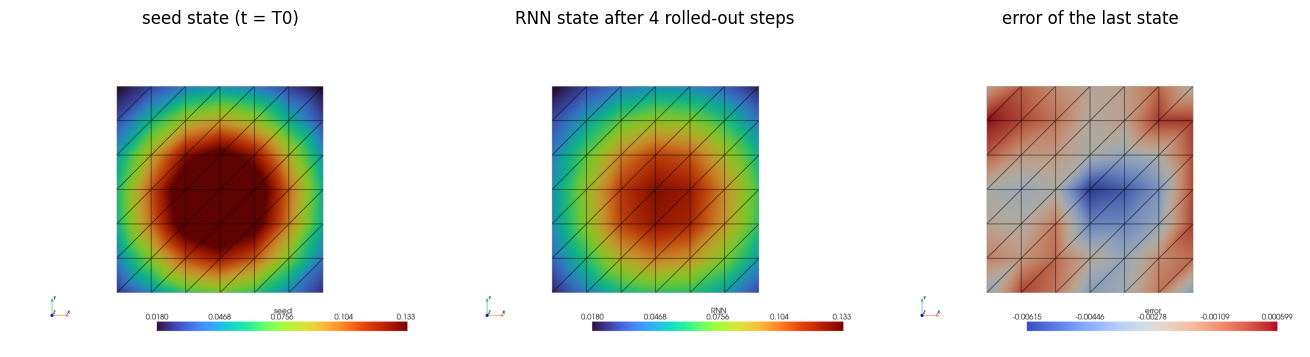

In [5]:
import matplotlib.pyplot as plt
from KratosMultiphysics import pyvista_utilities as pv_utils

for node, p, t in zip(deploy_part.Nodes, predicted, truth):
    node.SetValue(Kratos.NODAL_PAUX, float(p))        # RNN prediction at the last step
    node.SetValue(Kratos.NODAL_ERROR, float(p - t))   # its error
clim = [float(truth.min()), float(truth.max())]
img_seed = pv_utils.ScreenshotModelPart(deploy_part, filename=None, name=Kratos.TEMPERATURE, label="seed", cmap="turbo", clim=clim, view="xy")
img_pred = pv_utils.ScreenshotModelPart(deploy_part, filename=None, name=Kratos.NODAL_PAUX, label="RNN", cmap="turbo", clim=clim, view="xy")
img_err = pv_utils.ScreenshotModelPart(deploy_part, filename=None, name=Kratos.NODAL_ERROR, label="error", cmap="coolwarm", view="xy")
fig, axes = plt.subplots(1, 3, figsize=(13.200000000000001, 4.0))
for ax, (img, title) in zip(numpy.atleast_1d(axes), [(img_seed, 'seed state (t = T0)'), (img_pred, 'RNN state after 4 rolled-out steps'), (img_err, 'error of the last state')]):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.savefig('output/rnn_mesh.png', dpi=120, bbox_inches="tight"); plt.show()


## Where to go from here

- `Seq2SeqRNN` has the same signature with a multi-step input window — feed it stacked histories.
- Longer rollouts: increase `nr_tsteps`, or evaluate error growth first with
  `rollout_utils.EvaluateRollout`.
- For real transient physics, drive the export from an actual transient Kratos analysis (the export
  process plugs into any solution loop through `ExecuteFinalizeSolutionStep`).
